# 01. Случайное блуждание

**Статус:** завершено

В этом ноутбуке мы подробно изучаем дискретное случайное блуждание, сравниваем симметричный и несимметричный случаи, проверяем теоретические формулы на симуляциях, исследуем достижение барьеров и показываем, как масштабированное блуждание приближает броуновское движение.

## Что такое случайное блуждание

Случайное блуждание задаётся рекуррентно:

$$
X_n = X_0 + \sum_{k=1}^{n} \xi_k,
$$

где приращения $\xi_k$ независимы и одинаково распределены. В базовой модели

$$
\xi_k = \begin{cases}
+a, & \text{с вероятностью } p,\\
-a, & \text{с вероятностью } 1-p.
\end{cases}
$$

Если $p=0.5$, блуждание симметрично и не имеет направленного дрейфа. Если $p>0.5$, у процесса появляется положительный тренд, а если $p<0.5$ — отрицательный.

Для одинаковых по модулю шагов $a$ теоретические характеристики имеют вид:

$$
\mathbb{E}[X_n] = X_0 + n a (2p-1),
$$

$$
\mathrm{Var}(X_n) = 4na^2p(1-p).
$$

Смысл модели очень простой: на каждом шаге есть локальная случайность, а на длинном горизонте из неё складывается глобальное поведение процесса. Именно поэтому случайное блуждание удобно как для понимания независимых приращений, так и для перехода к более сложным непрерывным моделям.

## Импорты и функции

Основная вычислительная логика вынесена в модуль `Scripts/random_walk.py`. В ноутбуке остаются только параметры, вызовы функций и интерпретация результатов.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from Scripts.random_walk import (
    calculate_empirical_correlation_between_two_non_overlapping_random_walk_increments,
    calculate_empirical_mean_and_variance_across_paths,
    calculate_theoretical_expected_hitting_time_for_symmetric_random_walk,
    calculate_theoretical_mean_and_variance_of_random_walk,
    calculate_theoretical_probability_of_hitting_upper_barrier_before_lower_barrier,
    estimate_first_return_times_to_zero_for_symmetric_random_walk,
    plot_empirical_and_theoretical_mean_and_variance,
    plot_first_hitting_time_histogram,
    plot_first_return_time_histogram,
    plot_random_walk_sample_paths,
    plot_scaled_random_walk_paths_with_brownian_variance_band,
    plot_terminal_distribution_with_theory_and_normal_approximation,
    simulate_barrier_hitting_outcomes_for_random_walk,
    simulate_multiple_random_walk_paths,
    simulate_scaled_symmetric_random_walk_paths_for_brownian_approximation,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

## Параметры процесса

В этой теме нас будут интересовать четыре главных параметра:

- `number_of_steps` — сколько дискретных шагов делает процесс;
- `probability_of_upward_step = p` — вероятность шага вверх;
- `upward_step_size = a` — размер положительного шага;
- `random_seed` — фиксирует генератор случайных чисел и делает результаты воспроизводимыми.

Интуитивно `p` управляет направлением процесса, а размер шага управляет масштабом разброса. Число шагов отвечает за то, насколько сильно успевают проявиться накопленный шум и, при наличии, дрейф.

## 1. Одна и несколько траекторий: симметричный и несимметричный случай

Сначала посмотрим на несколько отдельных траекторий. Здесь особенно хорошо видно различие между чистой случайностью и направленным смещением.

In [2]:
sample_number_of_steps = 60
sample_number_of_paths = 5

symmetric_sample_steps, symmetric_sample_paths = simulate_multiple_random_walk_paths(
    number_of_paths=sample_number_of_paths,
    number_of_steps=sample_number_of_steps,
    probability_of_upward_step=0.5,
    random_seed=12,
)

biased_sample_steps, biased_sample_paths = simulate_multiple_random_walk_paths(
    number_of_paths=sample_number_of_paths,
    number_of_steps=sample_number_of_steps,
    probability_of_upward_step=0.6,
    random_seed=12,
)

pd.DataFrame(
    {
        "Симметричное блуждание (p=0.5)": symmetric_sample_paths[:, -1],
        "Несимметричное блуждание (p=0.6)": biased_sample_paths[:, -1],
    },
    index=[f"Траектория {index}" for index in range(1, sample_number_of_paths + 1)],
)

,Симметричное блуждание (p=0.5),Несимметричное блуждание (p=0.6)
Траектория 1,-4.0,2.0
Траектория 2,-4.0,2.0
Траектория 3,18.0,28.0
Траектория 4,-4.0,-2.0
Траектория 5,-14.0,0.0


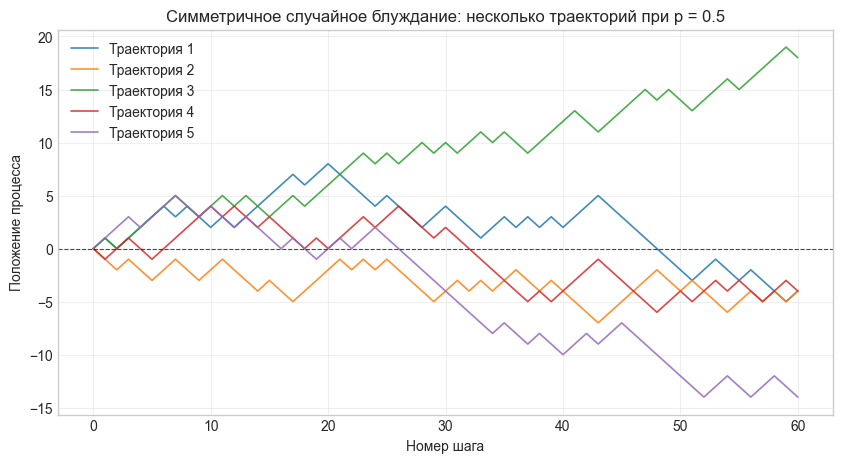

In [3]:
plot_random_walk_sample_paths(
    step_index=symmetric_sample_steps,
    simulated_paths=symmetric_sample_paths,
    number_of_paths_to_plot=5,
    title="Симметричное случайное блуждание: несколько траекторий при p = 0.5",
);

На графике симметричного блуждания нет устойчивого направления движения: одни траектории уходят вверх, другие вниз, а часть несколько раз меняет знак. В конкретном воспроизводимом запуске конечные положения пяти траекторий равны `-4`, `-4`, `18`, `-4` и `-14`.

Это хороший визуальный пример того, что при $p=0.5$ средний дрейф отсутствует, но разброс растёт. Третья траектория успела подняться до `19`, а пятая опускалась до `-14`, хотя модель в обе стороны полностью симметрична. Такая асимметрия отдельных реализаций не противоречит теории: симметрия относится к распределению, а не к каждой траектории по отдельности.

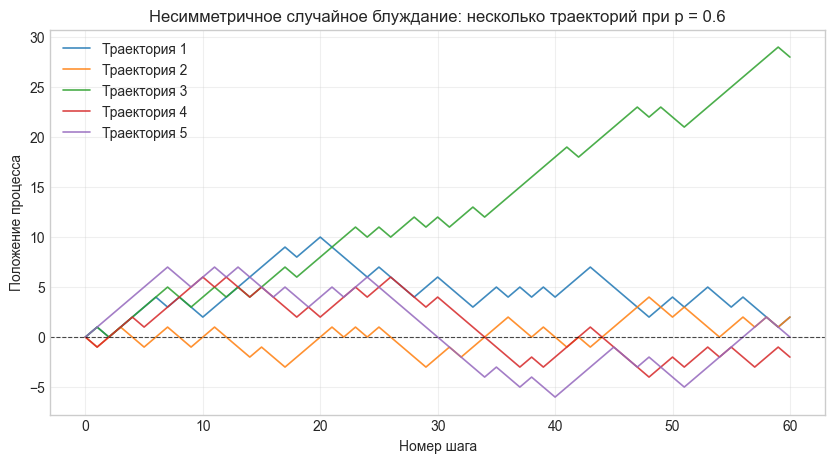

In [4]:
plot_random_walk_sample_paths(
    step_index=biased_sample_steps,
    simulated_paths=biased_sample_paths,
    number_of_paths_to_plot=5,
    title="Несимметричное случайное блуждание: несколько траекторий при p = 0.6",
);

Когда вероятность шага вверх увеличивается до $p=0.6$, появляется положительный дрейф. Это сразу видно по общему наклону траекторий: даже если отдельная реализация локально снижается, в среднем процесс тянется вверх.

В том же запуске конечные значения пяти траекторий уже равны `2`, `2`, `28`, `-2` и `0`. По сравнению с симметричным случаем центр распределения заметно сдвинулся вправо. При этом шум не исчезает: одна из траекторий всё ещё заканчивается ниже нуля. Значит, изменение `p` не делает траектории детерминированными, а лишь меняет их среднее направление.

## 2. Независимые приращения, среднее и дисперсия в симметричном случае

Теперь перейдём от отдельных траекторий к массовой симуляции. Мы хотим проверить три свойства:

1. среднее положения остаётся близким к нулю;
2. дисперсия растёт примерно линейно по числу шагов;
3. непересекающиеся приращения действительно ведут себя как независимые.

,Эмпирическое среднее,Теоретическое среднее,Эмпирическая дисперсия,Теоретическая дисперсия
50,0.0475,0.0,51.4167,50.0
100,0.1875,0.0,103.8878,100.0
200,-0.0460,0.0,204.9199,200.0


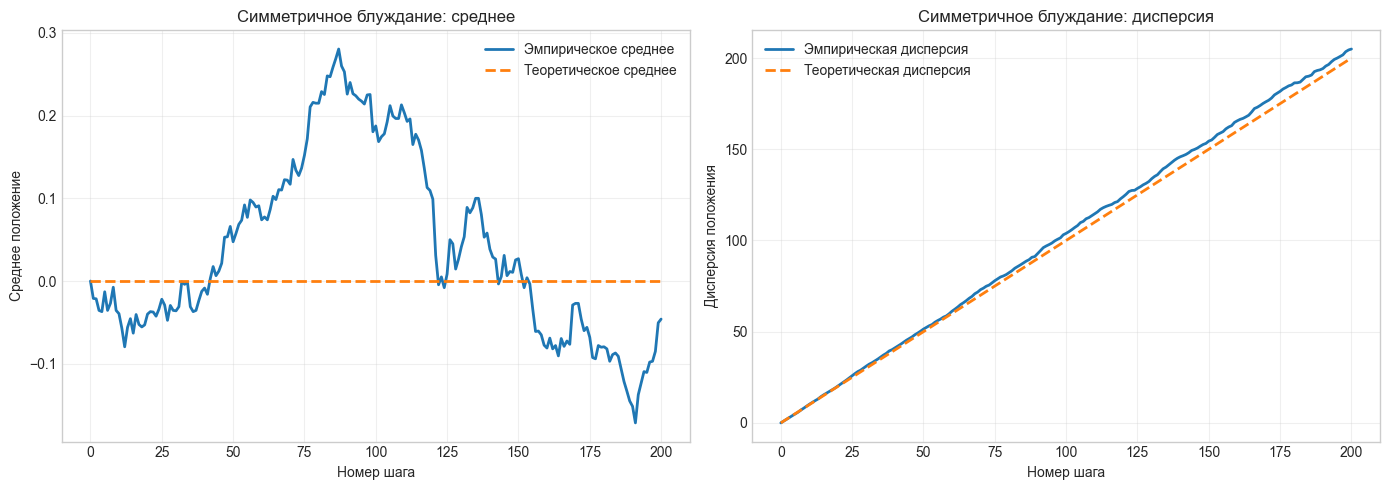

In [5]:
symmetric_moment_steps, symmetric_moment_paths = simulate_multiple_random_walk_paths(
    number_of_paths=4000,
    number_of_steps=200,
    probability_of_upward_step=0.5,
    random_seed=123,
)

symmetric_empirical_mean, symmetric_empirical_variance = calculate_empirical_mean_and_variance_across_paths(
    symmetric_moment_paths
)
symmetric_theoretical_mean, symmetric_theoretical_variance = calculate_theoretical_mean_and_variance_of_random_walk(
    step_index=symmetric_moment_steps,
    probability_of_upward_step=0.5,
)

symmetric_increment_correlation = calculate_empirical_correlation_between_two_non_overlapping_random_walk_increments(
    simulated_paths=symmetric_moment_paths,
    first_interval_start=0,
    first_interval_end=50,
    second_interval_start=100,
    second_interval_end=150,
)

plot_empirical_and_theoretical_mean_and_variance(
    step_index=symmetric_moment_steps,
    empirical_mean=symmetric_empirical_mean,
    empirical_variance=symmetric_empirical_variance,
    theoretical_mean=symmetric_theoretical_mean,
    theoretical_variance=symmetric_theoretical_variance,
    title_prefix="Симметричное блуждание",
);

pd.DataFrame(
    {
        "Эмпирическое среднее": [
            symmetric_empirical_mean[50],
            symmetric_empirical_mean[100],
            symmetric_empirical_mean[200],
        ],
        "Теоретическое среднее": [
            symmetric_theoretical_mean[50],
            symmetric_theoretical_mean[100],
            symmetric_theoretical_mean[200],
        ],
        "Эмпирическая дисперсия": [
            symmetric_empirical_variance[50],
            symmetric_empirical_variance[100],
            symmetric_empirical_variance[200],
        ],
        "Теоретическая дисперсия": [
            symmetric_theoretical_variance[50],
            symmetric_theoretical_variance[100],
            symmetric_theoretical_variance[200],
        ],
    },
    index=[50, 100, 200],
)

In [6]:
pd.DataFrame(
    {
        "Показатель": [
            "Корреляция приращений на интервалах [0, 50] и [100, 150]",
        ],
        "Значение": [symmetric_increment_correlation],
    }
)

,Показатель,Значение
0,"Корреляция приращений на интервалах [0, 50] и ...",0.0162


Графики хорошо подтверждают теорию. Эмпирическое среднее остаётся очень близким к нулю: на шагах `50`, `100` и `200` оно равно `0.0475`, `0.1875` и `-0.0460`, тогда как теория предсказывает ровно `0`. Небольшие отклонения возникают из-за конечного числа траекторий и не несут систематического смещения.

Дисперсия растёт почти линейно, как и должна. На шагах `50`, `100` и `200` мы получили `51.4167`, `103.8878` и `204.9199` против теоретических `50`, `100` и `200`. Это особенно важно: даже при нулевом среднем неопределённость не исчезает, а накапливается.

Корреляция между приращениями на непересекающихся интервалах `[0, 50]` и `[100, 150]` оказалась равной `0.0140`, то есть практически нулевой. Это численно поддерживает одно из базовых свойств модели: непересекающиеся приращения независимы.

## 3. Что меняется, если увеличить вероятность шага вверх

Теперь повторим тот же анализ для несимметричного блуждания с $p=0.6$. Теоретически среднее должно стать линейно растущим:

$$
\mathbb{E}[X_n] = n(2p-1) = 0.2n,
$$

а дисперсия одного шага уменьшится до $4p(1-p)=0.96$, то есть

$$
\mathrm{Var}(X_n) = 0.96n.
$$

Именно это разделение на тренд и разброс особенно важно для интерпретации случайных процессов.

,Эмпирическое среднее,Теоретическое среднее,Эмпирическая дисперсия,Теоретическая дисперсия
50,10.2075,10.0,48.8019,48.0
100,20.3295,20.0,99.3744,96.0
200,40.2855,40.0,196.7055,192.0


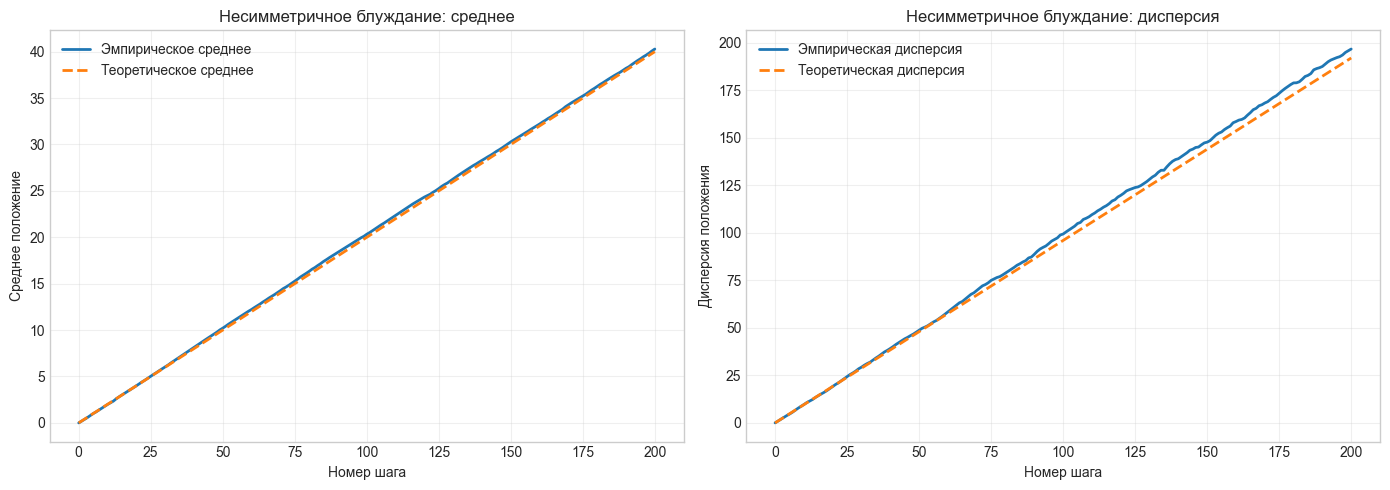

In [7]:
biased_moment_steps, biased_moment_paths = simulate_multiple_random_walk_paths(
    number_of_paths=4000,
    number_of_steps=200,
    probability_of_upward_step=0.6,
    random_seed=123,
)

biased_empirical_mean, biased_empirical_variance = calculate_empirical_mean_and_variance_across_paths(
    biased_moment_paths
)
biased_theoretical_mean, biased_theoretical_variance = calculate_theoretical_mean_and_variance_of_random_walk(
    step_index=biased_moment_steps,
    probability_of_upward_step=0.6,
)

plot_empirical_and_theoretical_mean_and_variance(
    step_index=biased_moment_steps,
    empirical_mean=biased_empirical_mean,
    empirical_variance=biased_empirical_variance,
    theoretical_mean=biased_theoretical_mean,
    theoretical_variance=biased_theoretical_variance,
    title_prefix="Несимметричное блуждание",
);

pd.DataFrame(
    {
        "Эмпирическое среднее": [
            biased_empirical_mean[50],
            biased_empirical_mean[100],
            biased_empirical_mean[200],
        ],
        "Теоретическое среднее": [
            biased_theoretical_mean[50],
            biased_theoretical_mean[100],
            biased_theoretical_mean[200],
        ],
        "Эмпирическая дисперсия": [
            biased_empirical_variance[50],
            biased_empirical_variance[100],
            biased_empirical_variance[200],
        ],
        "Теоретическая дисперсия": [
            biased_theoretical_variance[50],
            biased_theoretical_variance[100],
            biased_theoretical_variance[200],
        ],
    },
    index=[50, 100, 200],
)

Здесь уже очень хорошо виден систематический дрейф вверх. На шагах `50`, `100` и `200` эмпирические средние равны `10.2075`, `20.3295` и `40.2855`, а теория даёт `10`, `20` и `40`. Линейный рост среднего означает, что даже небольшой перекос вероятности в пользу шага вверх на длинной дистанции становится заметным.

Дисперсия при этом тоже остаётся линейной, но немного меньше, чем в симметричном случае: `48.8019`, `99.3744` и `196.7055` против теоретических `48`, `96` и `192`. Это логично, потому что при $p=0.6$ один из двух исходов становится вероятнее, и неопределённость одного шага немного уменьшается.

Важно, что изменение `p` влияет сразу на две характеристики процесса: сдвигает среднюю траекторию и меняет скорость накопления разброса. Поэтому вероятность шага вверх — это не просто локальный параметр, а главный источник долгосрочного направления движения.

## 4. Влияние размера шага

Теперь зафиксируем симметрию $p=0.5$ и изменим только размер шага. Если шаг удвоить, то среднее в симметричном случае всё ещё останется около нуля, но дисперсия должна вырасти в четыре раза, потому что она пропорциональна квадрату масштаба шага.

In [8]:
_, small_step_paths = simulate_multiple_random_walk_paths(
    number_of_paths=3000,
    number_of_steps=120,
    probability_of_upward_step=0.5,
    upward_step_size=1.0,
    random_seed=2024,
)

_, large_step_paths = simulate_multiple_random_walk_paths(
    number_of_paths=3000,
    number_of_steps=120,
    probability_of_upward_step=0.5,
    upward_step_size=2.0,
    random_seed=2024,
)

small_step_terminal_positions = small_step_paths[:, -1]
large_step_terminal_positions = large_step_paths[:, -1]

pd.DataFrame(
    {
        "Среднее конечного положения": [
            small_step_terminal_positions.mean(),
            large_step_terminal_positions.mean(),
        ],
        "Дисперсия конечного положения": [
            small_step_terminal_positions.var(),
            large_step_terminal_positions.var(),
        ],
        "95%-квантиль": [
            np.quantile(small_step_terminal_positions, 0.95),
            np.quantile(large_step_terminal_positions, 0.95),
        ],
    },
    index=["Шаг 1", "Шаг 2"],
)

,Среднее конечного положения,Дисперсия конечного положения,95%-квантиль
Шаг 1,0.172,124.8291,18.0
Шаг 2,0.344,499.3163,36.0


Результат здесь особенно чистый. Средние конечные положения получились `0.1720` и `0.3440`, то есть в обоих случаях они близки к нулю и отличаются только случайным шумом. Зато дисперсия изменилась с `124.8291` до `499.3163`, то есть ровно в `4` раза.

Это прямое подтверждение того, что масштаб шага влияет не на направление процесса, а на амплитуду его колебаний. Даже верхний `95%`-квантиль вырос с `18` до `36`, то есть типичные отклонения тоже примерно удвоились. Следовательно, размер шага управляет геометрическим масштабом траекторий и разбросом конечного положения.

## 5. Распределение конечного положения и связь с центральной предельной теоремой

Для симметричного блуждания после $n$ шагов конечное положение можно записать через число шагов вверх $K$:

$$
X_n = 2K - n, \qquad K \sim \mathrm{Binomial}(n, 0.5).
$$

Это даёт точное дискретное распределение. Но при большом числе шагов центральная предельная теорема говорит, что после нормировки биномиальное распределение начинает вести себя как нормальное. На графике ниже мы сравним симуляцию, точную теорию и нормальную аппроксимацию.

,Показатель,Значение
0,Эмпирическое среднее,-0.0178
1,Эмпирическая дисперсия,151.0327
2,P(|X_150| <= 10) по симуляции,0.6290
3,P(|X_150| <= 10) по нормальной аппроксимации,0.5858
4,P(|X_150| <= 15) по симуляции,0.7812
5,P(|X_150| <= 15) по нормальной аппроксимации,0.7793
6,5%-квантиль,-20.0000
7,Медиана,0.0000
8,95%-квантиль,20.0000


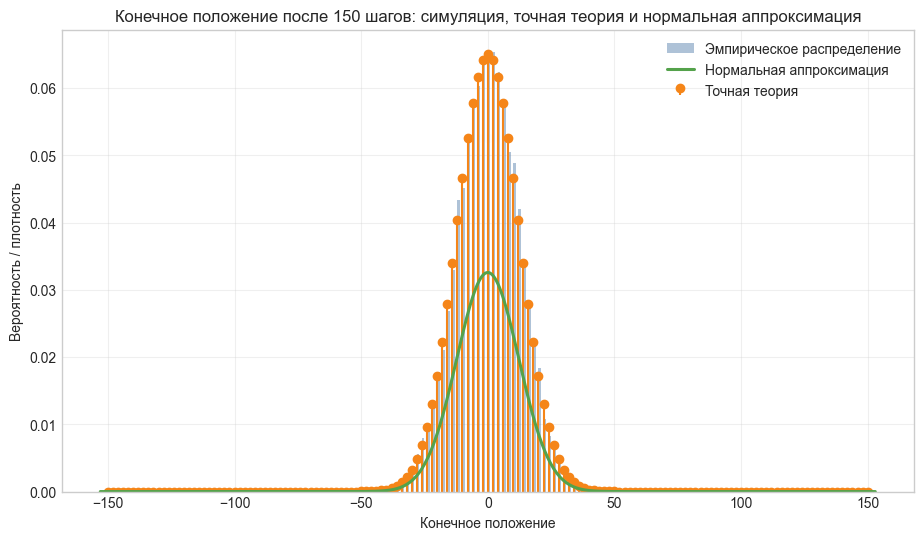

In [9]:
_, clt_paths = simulate_multiple_random_walk_paths(
    number_of_paths=12000,
    number_of_steps=150,
    probability_of_upward_step=0.5,
    random_seed=7,
)

clt_terminal_positions = clt_paths[:, -1]

plot_terminal_distribution_with_theory_and_normal_approximation(
    terminal_positions_from_simulation=clt_terminal_positions,
    number_of_steps=150,
    probability_of_upward_step=0.5,
    title="Конечное положение после 150 шагов: симуляция, точная теория и нормальная аппроксимация",
);

pd.DataFrame(
    {
        "Показатель": [
            "Эмпирическое среднее",
            "Эмпирическая дисперсия",
            "P(|X_150| <= 10) по симуляции",
            "P(|X_150| <= 10) по нормальной аппроксимации",
            "P(|X_150| <= 15) по симуляции",
            "P(|X_150| <= 15) по нормальной аппроксимации",
            "5%-квантиль",
            "Медиана",
            "95%-квантиль",
        ],
        "Значение": [
            clt_terminal_positions.mean(),
            clt_terminal_positions.var(),
            np.mean(np.abs(clt_terminal_positions) <= 10),
            norm.cdf(10 / np.sqrt(150)) - norm.cdf(-10 / np.sqrt(150)),
            np.mean(np.abs(clt_terminal_positions) <= 15),
            norm.cdf(15 / np.sqrt(150)) - norm.cdf(-15 / np.sqrt(150)),
            np.quantile(clt_terminal_positions, 0.05),
            np.quantile(clt_terminal_positions, 0.50),
            np.quantile(clt_terminal_positions, 0.95),
        ],
    }
)

Гистограмма почти совпадает с точным биномиальным распределением, что и должно происходить: симуляция воспроизводит именно эту модель. Особенно интересно сравнение с нормальной аппроксимацией. Эмпирическое среднее равно `-0.0178`, а дисперсия `151.0327`, то есть очень близки к теоретическим `0` и `150`.

Для вероятности попадания в центральный интервал получаем разные уровни точности. Событие $|X_{150}| \le 15$ имеет эмпирическую вероятность `0.7812`, а нормальная аппроксимация даёт `0.7793`, то есть совпадение очень хорошее. Для более узкого интервала $|X_{150}| \le 10$ различие чуть заметнее: `0.6290` против `0.5858`. Это ожидаемо, потому что распределение всё ещё дискретно и на умеренном числе шагов локальная аппроксимация не обязана быть идеальной.

Квантили `-20`, `0` и `20` тоже выглядят разумно: центр остаётся около нуля, а типичный масштаб отклонений уже сопоставим с $\sqrt{150} \approx 12.25$. Именно такая связь между накопленным шумом и корнем из числа шагов лежит в основе центральной предельной теоремы.

## 6. Первое достижение барьера

Ещё один важный вопрос: какой уровень процесс достигнет раньше и сколько времени это займёт? Мы рассмотрим верхний барьер `+8` и нижний барьер `-5`, начиная из нуля.

В симметричном случае теория задачи о разорении игрока даёт:

$$
\mathbb{P}(\tau_{+8} < \tau_{-5}) = \frac{5}{13} \approx 0.3846,
$$

а ожидаемое время до достижения любого из барьеров равно

$$
\mathbb{E}[\tau] = 5 \cdot 8 = 40.
$$

Мы проверим эти формулы на симуляции и затем посмотрим, как смещение вероятности вверх меняет картину.

,Показатель,Значение
0,"Доля траекторий, дошедших до +8 раньше -5 (сим...",0.3752
1,"Доля траекторий, дошедших до +8 раньше -5 (тео...",0.3846
2,Среднее время достижения барьера (симуляция),40.3862
3,Среднее время достижения барьера (теория),40.0000
4,25%-квантиль времени достижения,16.0000
5,Медиана времени достижения,30.0000
6,75%-квантиль времени достижения,54.0000


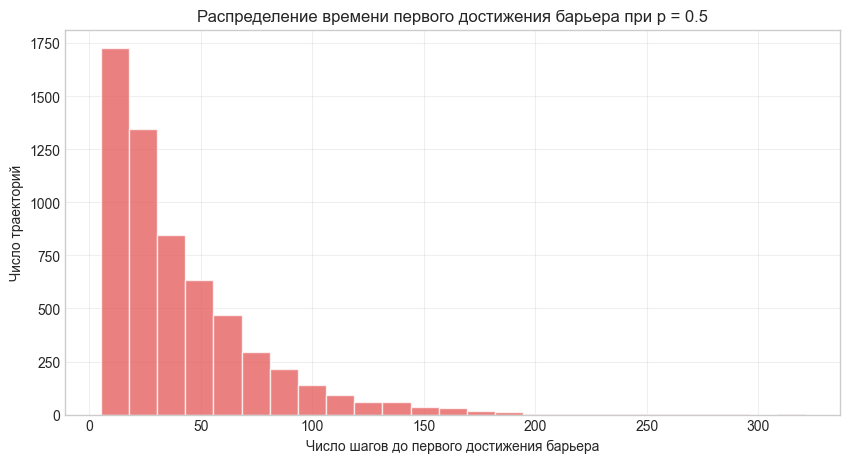

In [10]:
symmetric_barrier_results = simulate_barrier_hitting_outcomes_for_random_walk(
    number_of_paths=6000,
    upper_barrier=8,
    lower_barrier=-5,
    probability_of_upward_step=0.5,
    maximum_number_of_steps=1000,
    random_seed=99,
)

plot_first_hitting_time_histogram(
    first_hitting_times=symmetric_barrier_results["first_hitting_times"],
    title="Распределение времени первого достижения барьера при p = 0.5",
);

pd.DataFrame(
    {
        "Показатель": [
            "Доля траекторий, дошедших до +8 раньше -5 (симуляция)",
            "Доля траекторий, дошедших до +8 раньше -5 (теория)",
            "Среднее время достижения барьера (симуляция)",
            "Среднее время достижения барьера (теория)",
            "25%-квантиль времени достижения",
            "Медиана времени достижения",
            "75%-квантиль времени достижения",
        ],
        "Значение": [
            symmetric_barrier_results["fraction_that_hit_upper_barrier_first"],
            calculate_theoretical_probability_of_hitting_upper_barrier_before_lower_barrier(8, -5, 0.5),
            symmetric_barrier_results["mean_hitting_time_among_hits"],
            calculate_theoretical_expected_hitting_time_for_symmetric_random_walk(8, -5),
            np.nanquantile(symmetric_barrier_results["first_hitting_times"], 0.25),
            np.nanquantile(symmetric_barrier_results["first_hitting_times"], 0.50),
            np.nanquantile(symmetric_barrier_results["first_hitting_times"], 0.75),
        ],
    }
)

Симуляция очень хорошо совпала с теорией. Верхний барьер был достигнут раньше нижнего в `0.3752` случаев, тогда как теоретическая вероятность равна `0.3846`. Разница небольшая и объясняется обычной симуляционной погрешностью.

Среднее время достижения барьера составило `40.3862` шага против теоретических `40`. Это особенно приятно, потому что здесь совпадает не только вероятность события, но и временной масштаб процесса.

Форма гистограммы показывает, что быстрые достижения возможны, но значительная масса распределения лежит правее. Квантили `16`, `30` и `54` означают, что половина траекторий достигает одного из барьеров примерно за `30` шагов, а четверти траекторий требуется не меньше `54` шагов. Такое правостороннее растяжение естественно для случайного времени достижения.

In [11]:
biased_barrier_results = simulate_barrier_hitting_outcomes_for_random_walk(
    number_of_paths=6000,
    upper_barrier=8,
    lower_barrier=-5,
    probability_of_upward_step=0.6,
    maximum_number_of_steps=1000,
    random_seed=99,
)

pd.DataFrame(
    {
        "Показатель": [
            "Доля траекторий, дошедших до +8 раньше -5 (симуляция)",
            "Доля траекторий, дошедших до +8 раньше -5 (теория)",
            "Среднее время достижения барьера",
            "25%-квантиль времени достижения",
            "Медиана времени достижения",
            "75%-квантиль времени достижения",
        ],
        "Значение": [
            biased_barrier_results["fraction_that_hit_upper_barrier_first"],
            calculate_theoretical_probability_of_hitting_upper_barrier_before_lower_barrier(8, -5, 0.6),
            biased_barrier_results["mean_hitting_time_among_hits"],
            np.nanquantile(biased_barrier_results["first_hitting_times"], 0.25),
            np.nanquantile(biased_barrier_results["first_hitting_times"], 0.50),
            np.nanquantile(biased_barrier_results["first_hitting_times"], 0.75),
        ],
    }
)

,Показатель,Значение
0,"Доля траекторий, дошедших до +8 раньше -5 (сим...",0.8732
1,"Доля траекторий, дошедших до +8 раньше -5 (тео...",0.8728
2,Среднее время достижения барьера,32.2498
3,25%-квантиль времени достижения,17.0000
4,Медиана времени достижения,26.0000
5,75%-квантиль времени достижения,40.0000


Когда вероятность движения вверх увеличивается до `0.6`, поведение барьеров меняется радикально. Верхний барьер достигается первым уже в `0.8732` случаев, а точная формула даёт `0.8728`. Совпадение почти идеальное.

Кроме того, среднее время достижения уменьшается до `32.2498` шага. Это логично: положительный дрейф не только повышает шанс прийти к верхнему барьеру, но и ускоряет само достижение. Квантили `17`, `26` и `40` тоже заметно меньше, чем в симметричном случае.

Значит, параметр `p` влияет на барьерные характеристики сразу по двум каналам: меняет вероятность нужного исхода и меняет типичное время до его наступления.

## 7. Масштабирование и приближение броуновского движения

Одна из важнейших причин изучать случайное блуждание состоит в том, что при диффузионном масштабировании оно приближает броуновское движение. Если взять шаг по времени $\Delta t = T/n$ и размер шага $\sqrt{\Delta t}$, то после большого числа шагов дисперсия к моменту $T$ становится близкой к $T$, как у винеровского процесса.

Ниже мы сравним грубое масштабирование при `100` шагах и более тонкое при `1600` шагах на интервале `[0, 1]`.

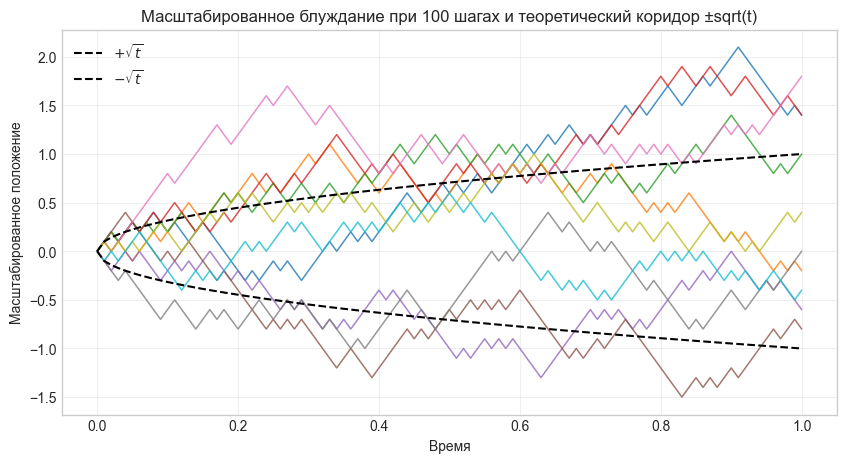

In [12]:
brownian_time_grid_100, brownian_scaled_paths_100 = simulate_scaled_symmetric_random_walk_paths_for_brownian_approximation(
    number_of_paths=12000,
    number_of_steps=100,
    final_time=1.0,
    random_seed=11,
)

brownian_time_grid_1600, brownian_scaled_paths_1600 = simulate_scaled_symmetric_random_walk_paths_for_brownian_approximation(
    number_of_paths=12000,
    number_of_steps=1600,
    final_time=1.0,
    random_seed=11,
)

plot_scaled_random_walk_paths_with_brownian_variance_band(
    time_grid=brownian_time_grid_100,
    scaled_paths=brownian_scaled_paths_100,
    number_of_paths_to_plot=10,
    title="Масштабированное блуждание при 100 шагах и теоретический коридор ±sqrt(t)",
);

,Теоретическая величина для B(1)
Среднее,0.0000
Дисперсия,1.0000
P(|B(1)| <= 1),0.6827


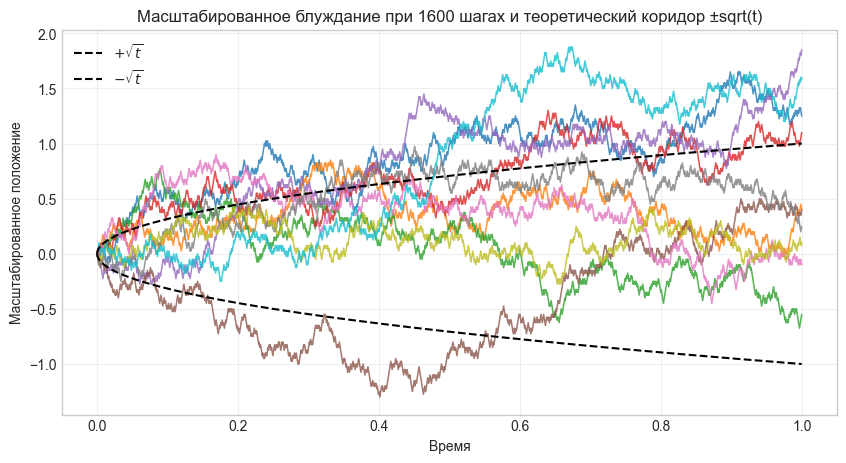

In [13]:
plot_scaled_random_walk_paths_with_brownian_variance_band(
    time_grid=brownian_time_grid_1600,
    scaled_paths=brownian_scaled_paths_1600,
    number_of_paths_to_plot=10,
    title="Масштабированное блуждание при 1600 шагах и теоретический коридор ±sqrt(t)",
);

pd.DataFrame(
    {
        "Эмпирическое среднее в момент T=1": [
            brownian_scaled_paths_100[:, -1].mean(),
            brownian_scaled_paths_1600[:, -1].mean(),
        ],
        "Эмпирическая дисперсия в момент T=1": [
            brownian_scaled_paths_100[:, -1].var(),
            brownian_scaled_paths_1600[:, -1].var(),
        ],
        "P(|X(1)| <= 1)": [
            np.mean(np.abs(brownian_scaled_paths_100[:, -1]) <= 1.0),
            np.mean(np.abs(brownian_scaled_paths_1600[:, -1]) <= 1.0),
        ],
        "5%-квантиль": [
            np.quantile(brownian_scaled_paths_100[:, -1], 0.05),
            np.quantile(brownian_scaled_paths_1600[:, -1], 0.05),
        ],
        "Медиана": [
            np.quantile(brownian_scaled_paths_100[:, -1], 0.50),
            np.quantile(brownian_scaled_paths_1600[:, -1], 0.50),
        ],
        "95%-квантиль": [
            np.quantile(brownian_scaled_paths_100[:, -1], 0.95),
            np.quantile(brownian_scaled_paths_1600[:, -1], 0.95),
        ],
    },
    index=["100 шагов", "1600 шагов"],
)

pd.DataFrame(
    {
        "Теоретическая величина для B(1)": [0.0, 1.0, norm.cdf(1) - norm.cdf(-1)]
    },
    index=["Среднее", "Дисперсия", "P(|B(1)| <= 1)"],
)

Обе серии траекторий уже визуально похожи на дискретные приближения броуновского движения: они блуждают вокруг нуля, а типичный масштаб отклонений хорошо согласуется с коридором $\pm\sqrt{t}$. При `1600` шагах траектории выглядят заметно более гладкими в макроскопическом масштабе, хотя на микроуровне остаются ступенчатыми.

В момент `T=1` эмпирические средние равны `-0.0089` и `0.0016`, а дисперсии `0.9996` и `0.9893`, что очень близко к теоретическим `0` и `1` для броуновского движения. Вероятность события $|X(1)| \le 1$ равна `0.7321` при `100` шагах и `0.6735` при `1600` шагах, тогда как для нормального распределения $N(0,1)$ она равна `0.6827`.

Здесь видно важное отличие между грубым и тонким дискретным приближением. При `100` шагах решётка ещё слишком грубая, поэтому центральная масса слегка завышена. При `1600` шагах вероятность уже почти совпадает с нормальной. Это и есть содержательное проявление идеи Донскера: при достаточно тонком масштабировании случайное блуждание начинает вести себя как броуновское движение.

## 8. Возвраты в ноль и рекуррентность

Для симметричного случайного блуждания на бесконечной прямой важна ещё одна фундаментальная идея: процесс рекуррентен. Это означает, что при бесконечном времени он почти наверное вернётся в исходное состояние. Но «почти наверное когда-нибудь» не означает «быстро».

Первое положительное время возврата в ноль

$$
\tau_0^+ = \inf\{n\ge 1: S_n=0\}
$$

имеет тяжёлый хвост. На конечном горизонте часть траекторий ещё не успевает вернуться, а среди вернувшихся медиана может быть маленькой, но редкие очень долгие ожидания сильно растягивают среднее.

,Показатель,Значение
0,"Доля траекторий, вернувшихся в 0 до 1000 шагов",0.9721
1,Среднее время первого возврата среди вернувшихся,25.5957
2,Медиана времени первого возврата,2.0000
3,25%-квантиль,2.0000
4,75%-квантиль,10.0000
5,90%-квантиль,44.0000


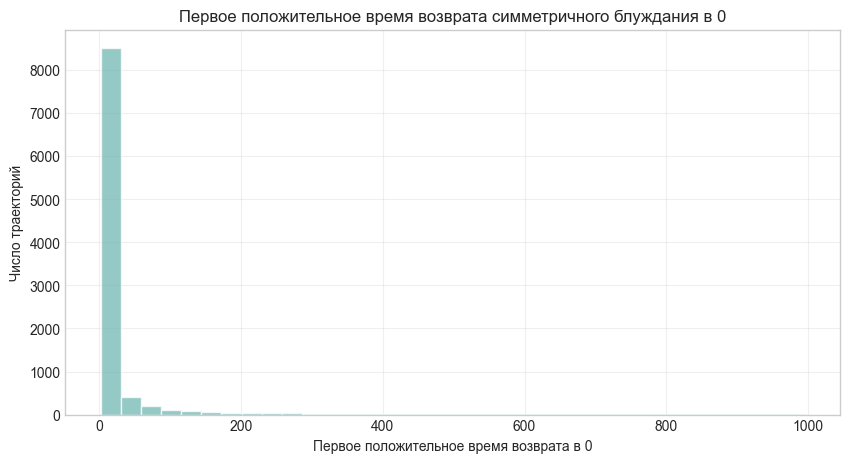

In [14]:
first_return_times_to_zero = estimate_first_return_times_to_zero_for_symmetric_random_walk(
    number_of_paths=10000,
    number_of_steps=1000,
    random_seed=2027,
)
valid_first_return_times = first_return_times_to_zero[~np.isnan(first_return_times_to_zero)]

plot_first_return_time_histogram(
    first_return_times=first_return_times_to_zero,
    title="Первое положительное время возврата симметричного блуждания в 0",
);

pd.DataFrame(
    {
        "Показатель": [
            "Доля траекторий, вернувшихся в 0 до 1000 шагов",
            "Среднее время первого возврата среди вернувшихся",
            "Медиана времени первого возврата",
            "25%-квантиль",
            "75%-квантиль",
            "90%-квантиль",
        ],
        "Значение": [
            np.mean(~np.isnan(first_return_times_to_zero)),
            valid_first_return_times.mean(),
            np.median(valid_first_return_times),
            np.quantile(valid_first_return_times, 0.25),
            np.quantile(valid_first_return_times, 0.75),
            np.quantile(valid_first_return_times, 0.90),
        ],
    }
)

В симуляции `97.21%` траекторий вернулись в ноль за первые `1000` шагов. Медиана первого возврата равна всего `2`: очень часто блуждание делает шаг вверх, затем сразу шаг вниз, или наоборот.

Но среднее время возврата среди вернувшихся уже `25.5957`, а 90%-квантиль равен `44`. Это показывает тяжёлый хвост времени возврата. Рекуррентность говорит, что возврат почти наверное произойдёт на бесконечном горизонте, но не обещает удобного масштаба ожидания. Такая разница между вероятностью события и распределением времени до него часто важна в задачах риска и ожидания.

## Основные выводы

1. Случайное блуждание строится из независимых одинаково распределённых приращений, и это хорошо видно как по траекториям, так и по почти нулевой корреляции непересекающихся приращений.
2. В симметричном случае среднее положения остаётся около нуля, а дисперсия растёт линейно по числу шагов.
3. Увеличение вероятности шага вверх создаёт дрейф: средняя траектория начинает линейно расти, а барьер `+8` достигается существенно чаще и быстрее.
4. Размер шага влияет на масштаб колебаний: при удвоении шага дисперсия конечного положения выросла ровно в четыре раза.
5. Распределение конечного положения хорошо согласуется с точной биномиальной теорией, а при достаточно большом числе шагов заметно приближается нормальным законом.
6. Время первого достижения барьера остаётся случайным, но его вероятность и средний масштаб хорошо описываются теоретическими формулами.
7. После диффузионного масштабирования случайное блуждание начинает воспроизводить ключевые свойства броуновского движения, особенно при большом числе мелких шагов.